# EfficientNet-B0による白血球5クラス分類

BBBC045の`ch5`画像を使ったEfficientNet-B0版です。

このNotebookでは、Simple CNN版と同じsubject-level split・class weight・評価指標を使い、モデル本体だけをEfficientNet-B0へ置き換えます。

処理の流れ：

`metadata → Train統計量 → Normalization → 55×55から224×224へResize → 1chから3chへ変換 → EfficientNet-B0 → Weighted CrossEntropy → Validation評価`

**Test splitはモデル選択には使いません。** 最終モデルが確定してから評価します。


In [17]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 1. Device / reproducibility

In [18]:
torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.7.0+cu128
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 2. Metadataの読み込み

In [19]:
PROJECT_DIR = Path(
    r"C:\Users\User\Desktop\白血球画像分類"
)

PROCESSED_DIR = PROJECT_DIR / "processed"

METADATA_PATH = (
    PROJECT_DIR / "metadata_with_split.csv"
)

metadata_df = pd.read_csv(METADATA_PATH)

metadata_df.head()


,subject,class_name,batch,montage_id,cell_id,row,col,ch1_path,ch3_path,ch5_path,subject_group,split
0,CRF034,B,batch1,1,0,0,0,CRF034\B\batch1\montage_1\cell_0000_ch1.tif,CRF034\B\batch1\montage_1\cell_0000_ch3.tif,CRF034\B\batch1\montage_1\cell_0000_ch5.tif,CRF034,train
1,CRF034,B,batch1,1,1,0,1,CRF034\B\batch1\montage_1\cell_0001_ch1.tif,CRF034\B\batch1\montage_1\cell_0001_ch3.tif,CRF034\B\batch1\montage_1\cell_0001_ch5.tif,CRF034,train
2,CRF034,B,batch1,1,2,0,2,CRF034\B\batch1\montage_1\cell_0002_ch1.tif,CRF034\B\batch1\montage_1\cell_0002_ch3.tif,CRF034\B\batch1\montage_1\cell_0002_ch5.tif,CRF034,train
3,CRF034,B,batch1,1,3,0,3,CRF034\B\batch1\montage_1\cell_0003_ch1.tif,CRF034\B\batch1\montage_1\cell_0003_ch3.tif,CRF034\B\batch1\montage_1\cell_0003_ch5.tif,CRF034,train
4,CRF034,B,batch1,1,4,0,4,CRF034\B\batch1\montage_1\cell_0004_ch1.tif,CRF034\B\batch1\montage_1\cell_0004_ch3.tif,CRF034\B\batch1\montage_1\cell_0004_ch5.tif,CRF034,train


## 3. Train / Validation / Test に分ける

In [20]:
train_df = metadata_df[
    metadata_df["split"] == "train"
].copy()

val_df = metadata_df[
    metadata_df["split"] == "val"
].copy()

test_df = metadata_df[
    metadata_df["split"] == "test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Train: 60649
Validation: 17303
Test: 22153


## 4. クラス名 → 数字ラベル

In [21]:
cell_type = {
    "B": 0,
    "T": 1,
    "eosinophil": 2,
    "monocyte": 3,
    "neutrophil": 4
}

class_names = [
    "B",
    "T",
    "eosinophil",
    "monocyte",
    "neutrophil"
]

print(cell_type)


{'B': 0, 'T': 1, 'eosinophil': 2, 'monocyte': 3, 'neutrophil': 4}


## 5. Train画像からmean / stdを計算

ValidationやTestの情報を使わないため、Normalizationに使う平均値と標準偏差は**Train画像だけ**から計算します。

標準化は

\[
x' = \frac{x-\mu_{train}}{\sigma_{train}}
\]

です。

言葉では、「各pixelからTrain全体の平均を引いて、Train全体の標準偏差で割る」です。


In [22]:
class WBCStatsDataset(Dataset):

    def __init__(self, dataframe, image_dir, channel):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.channel = channel

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_path = (
            self.image_dir
            / row[self.channel]
        )

        image = tifffile.imread(img_path)

        image_tensor = torch.from_numpy(
            image
        ).float()

        # (55, 55) -> (1, 55, 55)
        image_tensor = image_tensor.unsqueeze(0)

        return image_tensor


In [23]:
stats_dataset = WBCStatsDataset(
    dataframe=train_df,
    image_dir=PROCESSED_DIR,
    channel="ch5_path"
)

stats_loader = DataLoader(
    stats_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

pixel_sum = 0.0
pixel_squared_sum = 0.0
num_pixels = 0

for images in tqdm(
    stats_loader,
    desc="Calculating mean/std"
):
    # doubleで集計して数値誤差を小さくする
    images = images.double()

    pixel_sum += images.sum().item()
    pixel_squared_sum += (images ** 2).sum().item()
    num_pixels += images.numel()

train_mean = pixel_sum / num_pixels

train_variance = (
    pixel_squared_sum / num_pixels
    - train_mean ** 2
)

train_std = train_variance ** 0.5

print("Train mean:", train_mean)
print("Train std:", train_std)


Calculating mean/std:   0%|          | 0/1896 [00:00<?, ?it/s]

Train mean: 0.003398375998519426
Train std: 0.00016185119052088544


## 6. EfficientNet用Dataset

EfficientNet-B0用に画像を次の形へ変換します。

`(55, 55) → (1, 55, 55) → Normalize → (1, 224, 224) → (3, 224, 224)`

3channel化はRGB情報を新しく作るのではなく、同じ顕微鏡画像を3channelへ複製しています。


In [24]:
class WBCDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        channel,
        mean,
        std
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.channel = channel
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_path = (
            self.image_dir
            / row[self.channel]
        )

        # Read image file on the directory
        image = tifffile.imread(img_path)

        class_name = row["class_name"]
        label = cell_type[class_name]

        # Convert extracted image to tensor
        image_tensor = torch.from_numpy(
            image
        ).float()

        # Add channel dimension
        # (55, 55) -> (1, 55, 55)
        image_tensor = image_tensor.unsqueeze(0)

        # Normalize using Train mean/std
        image_tensor = (
            image_tensor - self.mean
        ) / (self.std + 1e-8)

        # Resize for EfficientNet
        # (1, 55, 55) -> (1, 224, 224)
        image_tensor = F.interpolate(
            image_tensor.unsqueeze(0),
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        # Convert 1 channel to 3 channels
        # (1, 224, 224) -> (3, 224, 224)
        image_tensor = image_tensor.repeat(
            3, 1, 1
        )

        return image_tensor, label


In [25]:
train_dataset = WBCDataset(
    dataframe=train_df,
    image_dir=PROCESSED_DIR,
    channel="ch5_path",
    mean=train_mean,
    std=train_std
)

val_dataset = WBCDataset(
    dataframe=val_df,
    image_dir=PROCESSED_DIR,
    channel="ch5_path",
    mean=train_mean,
    std=train_std
)

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Class:", train_df.iloc[0]["class_name"])


Image shape: torch.Size([3, 224, 224])
Label: 0
Class: B


## 7. DataLoader

In [26]:
# RTX 3050 Ti Laptop GPUを考慮して、まずbatch_size=16から開始
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

# Expected:
# Images shape: [16, 3, 224, 224]
# Labels shape: [16]


Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])


## 8. Pretrained EfficientNet-B0

In [27]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

# ImageNet 1000クラス分類用の最後のLinear層を
# 今回の白血球5クラス分類用へ変更
num_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    num_features,
    len(cell_type)
)

model = model.to(device)

print(model.classifier)


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [28]:
# Forward propagation sanity check
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)
print("Output shape:", outputs.shape)

# Expected output shape: [batch_size, 5]


Input shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Output shape: torch.Size([16, 5])


## 9. Class weight / Loss / Optimizer

Simple CNN版と同じclass weightを使います。

各クラスの重みは

\[
w_c = \frac{N}{K n_c}
\]

です。

- \(N\): Train全データ数
- \(K\): クラス数
- \(n_c\): そのクラスのTrain画像数

EfficientNetはImageNetで事前学習済みなので、最初はSimple CNNより小さいlearning rate (`1e-4`) で全層をfine-tuningします。


In [29]:
# ----- Class weights -----

class_counts = train_df["class_name"].value_counts()

num_samples = len(train_df)
num_classes = len(cell_type)

class_weights_list = []

for class_name, class_idx in sorted(
    cell_type.items(),
    key=lambda x: x[1]
):
    count = class_counts[class_name]

    weight = num_samples / (
        num_classes * count
    )

    class_weights_list.append(weight)

    print(
        class_name,
        "count =", count,
        "weight =", weight
    )

class_weights = torch.tensor(
    class_weights_list,
    dtype=torch.float32,
    device=device
)

# Weighted loss function
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Fine-tune all EfficientNet layers with a smaller learning rate
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


B count = 2079 weight = 5.834439634439635
T count = 14104 weight = 0.8600255246738514
eosinophil count = 2406 weight = 5.041479634247714
monocyte count = 2231 weight = 5.436934110264455
neutrophil count = 39829 weight = 0.3045469381606367


## 10. 1 epochのTraining関数

In [30]:
def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc="Training"
    )

    for images, labels in progress_bar:

        # Move data to GPU
        images = images.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )

        # Reset previous gradient
        optimizer.zero_grad()

        # Forward propagation
        outputs = model(images)

        # Loss function
        loss = criterion(outputs, labels)

        # Back propagation
        loss.backward()

        # Update weight using gradient from backprop
        optimizer.step()

        # ----- Loss -----
        running_loss += (
            loss.item() * images.size(0)
        )

        # ----- Accuracy -----
        predicted = outputs.argmax(dim=1)

        correct += (
            predicted == labels
        ).sum().item()

        total += labels.size(0)

        current_accuracy = (
            100 * correct / total
        )

        # Progress display
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{current_accuracy:.2f}%"
        )

    average_loss = running_loss / total
    accuracy = 100 * correct / total

    return average_loss, accuracy


## 11. 1 epochのValidation関数

In [31]:
def validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        val_loader,
        desc="Validation"
    )

    with torch.no_grad():

        for images, labels in progress_bar:

            images = images.to(
                device,
                non_blocking=True
            )
            labels = labels.to(
                device,
                non_blocking=True
            )

            # Forward propagation only
            outputs = model(images)

            # Loss function
            loss = criterion(outputs, labels)

            running_loss += (
                loss.item() * images.size(0)
            )

            predicted = outputs.argmax(dim=1)

            correct += (
                predicted == labels
            ).sum().item()

            total += labels.size(0)

            current_accuracy = (
                100 * correct / total
            )

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                accuracy=f"{current_accuracy:.2f}%"
            )

    average_loss = running_loss / total
    accuracy = 100 * correct / total

    return average_loss, accuracy


## 12. Training

まず10 epochで確認します。  
最終epochではなく、**Validation Lossが最も小さかったモデル**を保存します。


In [32]:
num_epochs = 10

train_loss_history = []
train_accuracy_history = []

val_loss_history = []
val_accuracy_history = []

best_val_loss = float("inf")
best_epoch = 0

MODEL_PATH = "best_efficientnet_b0.pth"

for epoch in range(num_epochs):

    print(
        f"\nEpoch {epoch + 1}/{num_epochs}"
    )

    train_loss, train_accuracy = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )
    )

    val_loss, val_accuracy = (
        validate_one_epoch(
            model,
            val_loader,
            criterion,
            device
        )
    )

    train_loss_history.append(train_loss)
    train_accuracy_history.append(
        train_accuracy
    )

    val_loss_history.append(val_loss)
    val_accuracy_history.append(
        val_accuracy
    )

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.2f}%"
    )

    print(
        f"Validation Loss: {val_loss:.4f} | "
        f"Validation Accuracy: {val_accuracy:.2f}%"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print("Best model saved!")

print(
    f"\nBest epoch: {best_epoch} | "
    f"Best Validation Loss: {best_val_loss:.4f}"
)



Epoch 1/10


Training:   0%|          | 0/3791 [00:00<?, ?it/s]

Validation:   0%|          | 0/1082 [00:00<?, ?it/s]

Train Loss: 0.3028 | Train Accuracy: 91.34%
Validation Loss: 0.1532 | Validation Accuracy: 94.92%
Best model saved!

Epoch 2/10


Training:   0%|          | 0/3791 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/1082 [00:00<?, ?it/s]

Train Loss: 0.0428 | Train Accuracy: 98.83%
Validation Loss: 0.1341 | Validation Accuracy: 96.57%

Epoch 10/10


Training:   0%|          | 0/3791 [00:00<?, ?it/s]

Validation:   0%|          | 0/1082 [00:00<?, ?it/s]

Train Loss: 0.0348 | Train Accuracy: 99.03%
Validation Loss: 0.1893 | Validation Accuracy: 91.63%

Best epoch: 5 | Best Validation Loss: 0.1118


## 13. 学習曲線

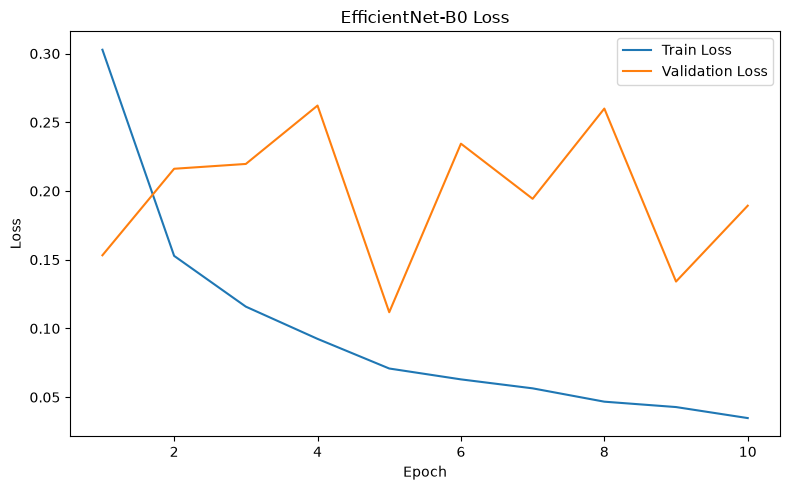

In [33]:
epochs = range(
    1,
    len(train_loss_history) + 1
)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    train_loss_history,
    label="Train Loss"
)
plt.plot(
    epochs,
    val_loss_history,
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Loss")
plt.legend()
plt.tight_layout()
plt.show()


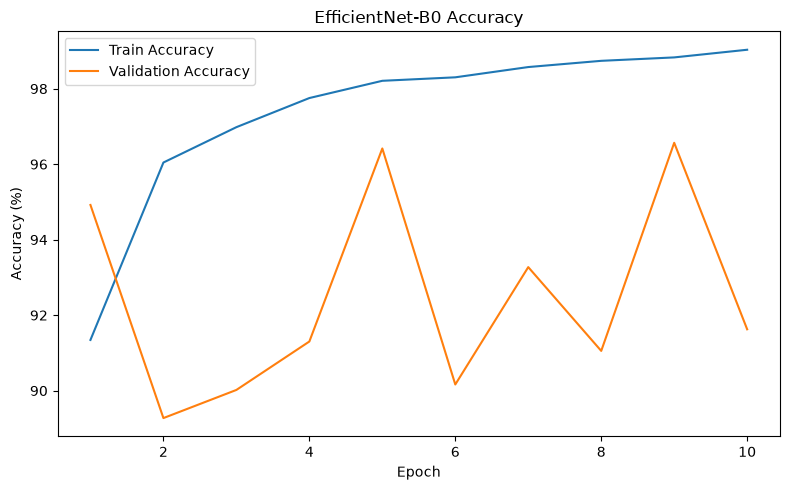

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    train_accuracy_history,
    label="Train Accuracy"
)
plt.plot(
    epochs,
    val_accuracy_history,
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B0 Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


## 14. Best modelを読み戻してValidation評価

ここでは20 epoch目など「最後のモデル」ではなく、Training中に保存した**best model**を評価します。


In [35]:
model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in tqdm(
        val_loader,
        desc="Collecting validation predictions"
    ):

        images = images.to(
            device,
            non_blocking=True
        )
        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        predicted = outputs.argmax(dim=1)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )


## 15. Accuracy / Macro Precision / Recall / F1

In [36]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

print()
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        zero_division=0
    )
)


Validation Accuracy: 0.9642
Macro Precision: 0.9132
Macro Recall: 0.9556
Macro F1: 0.9325

              precision    recall  f1-score   support

           B       0.75      0.90      0.82      1249
           T       0.99      0.94      0.96      6669
  eosinophil       0.95      0.99      0.97       421
    monocyte       0.89      0.96      0.92      1051
  neutrophil       1.00      0.99      1.00      7913

    accuracy                           0.96     17303
   macro avg       0.91      0.96      0.93     17303
weighted avg       0.97      0.96      0.97     17303



## 16. Confusion Matrix（件数）

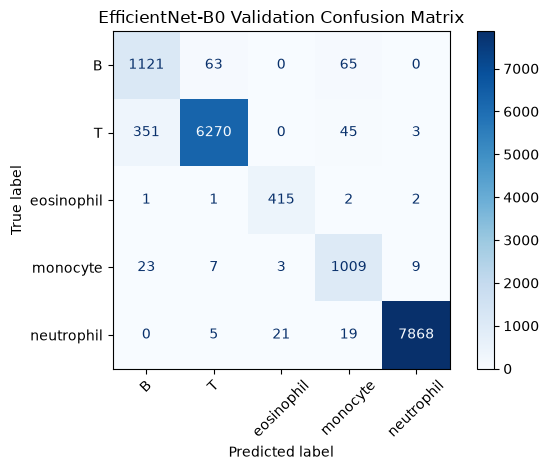

In [37]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title(
    "EfficientNet-B0 Validation Confusion Matrix"
)
plt.tight_layout()
plt.show()


## 17. Confusion Matrix（クラスごとの割合）

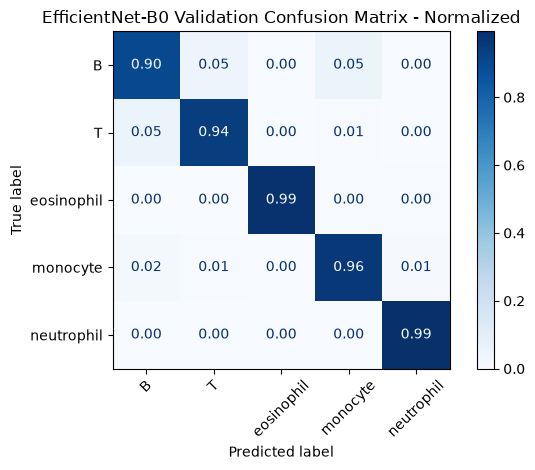

In [38]:
cm_normalized = confusion_matrix(
    all_labels,
    all_predictions,
    normalize="true"
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)

display.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format=".2f"
)

plt.title(
    "EfficientNet-B0 Validation Confusion Matrix - Normalized"
)
plt.tight_layout()
plt.show()


## 18. Validation画像と予測結果を確認

数値だけでなく、実際の細胞画像と`True / Pred`を確認します。  
表示時だけNormalizationを戻して、元の明るさスケールに近い画像を表示します。


In [40]:
model.eval()

# 各クラス2枚ずつ表示
samples_per_class = 2

selected_images = {
    class_name: []
    for class_name in class_names
}

with torch.no_grad():

    for images, labels in val_loader:

        images_gpu = images.to(device)

        outputs = model(images_gpu)

        predictions = (
            outputs.argmax(dim=1).cpu()
        )

        for i in range(len(images)):

            true_idx = labels[i].item()
            pred_idx = predictions[i].item()

            true_name = class_names[true_idx]
            pred_name = class_names[pred_idx]

            # 正しく予測された画像だけ集める
            if (
                true_idx == pred_idx
                and len(selected_images[true_name])
                < samples_per_class
            ):

                selected_images[true_name].append(
                    (
                        images[i].cpu(),
                        true_name,
                        pred_name
                    )
                )

        # 全クラス必要枚数集まったら終了
        if all(
            len(selected_images[class_name])
            >= samples_per_class
            for class_name in class_names
        ):
            break

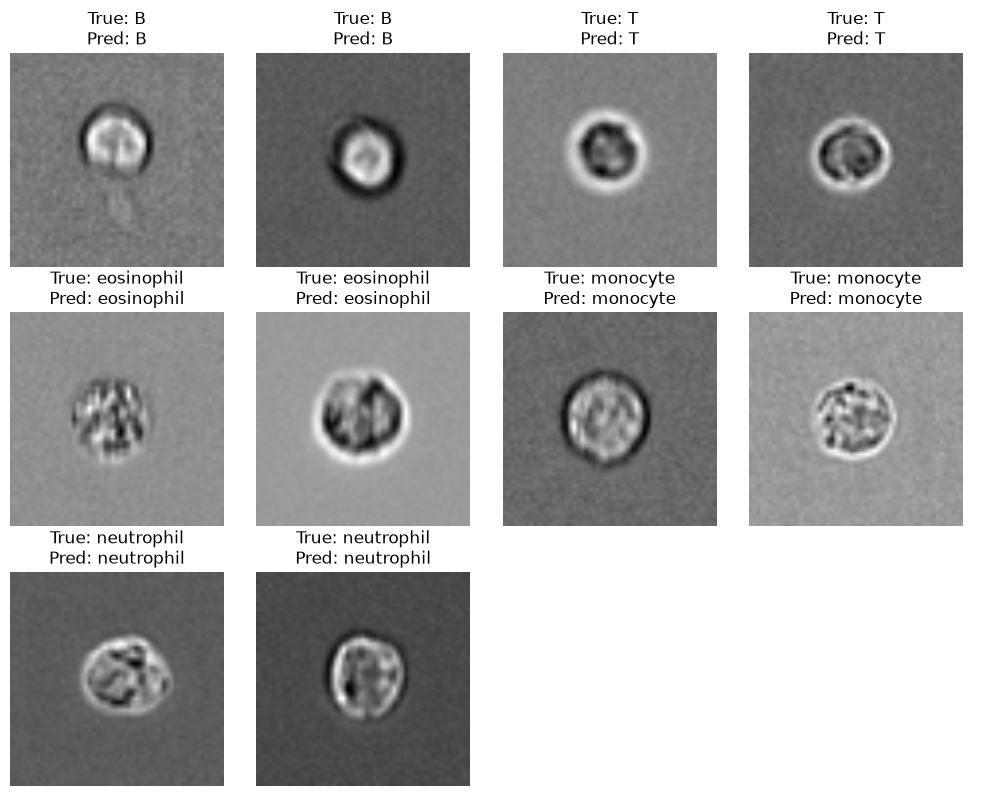

In [42]:
# 5 classes × 2 images = 10 images
display_samples = []

for class_name in class_names:
    display_samples.extend(
        selected_images[class_name]
    )

fig, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

axes = axes.flatten()

for i, (
    image,
    true_name,
    pred_name
) in enumerate(display_samples):

    # First channel only
    # Undo Train normalization
    image_for_display = (
        image[0].numpy()
        * train_std
        + train_mean
    )

    axes[i].imshow(
        image_for_display,
        cmap="gray"
    )

    axes[i].set_title(
        f"True: {true_name}\nPred: {pred_name}"
    )

    axes[i].axis("off")

# 残った2枠を非表示
for i in range(
    len(display_samples),
    len(axes)
):
    axes[i].axis("off")

plt.tight_layout()
plt.show()